In [1]:
import pandas as pd

# A verified, working raw link to the Insurance dataset on GitHub
insurance_url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"

# Read the CSV file directly from the web link
df = pd.read_csv(insurance_url)

# Check the size of our dataset (Rows, Columns)
print("Dataset Dimensions:", df.shape)

# Look at the top 5 rows
print("\n--- Top 5 Insurance Rows ---")
df.head()

Dataset Dimensions: (1338, 7)

--- Top 5 Insurance Rows ---


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
# 1. Get a summary of columns, data types, and missing values
print("--- Data Information ---")
df.info()

# 2. Check explicitly for any missing (null) values in each column
print("\n--- Missing Values Count ---")
print(df.isnull().sum())

--- Data Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

--- Missing Values Count ---
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [3]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [4]:
# Group the data by 'smoker' and calculate the average 'charges'
smoker_analysis = df.groupby('smoker')['charges'].mean()

print("--- Average Charges: Smoker vs Non-Smoker ---")
print(smoker_analysis)

--- Average Charges: Smoker vs Non-Smoker ---
smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64


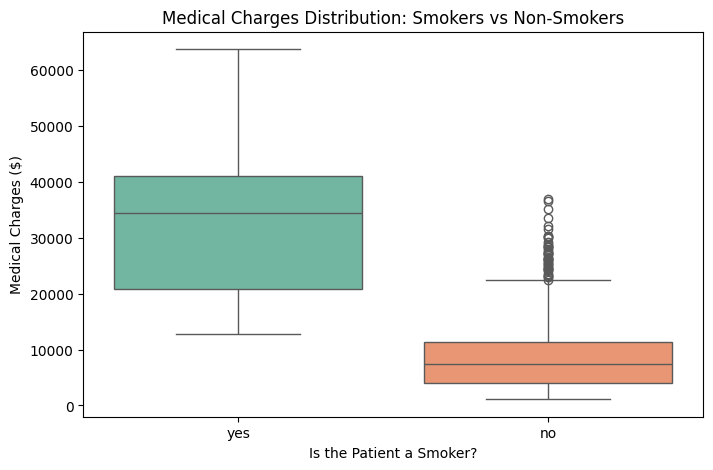

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the updated box plot (warning-free!)
plt.figure(figsize=(8, 5))
sns.boxplot(x='smoker', y='charges', data=df, hue='smoker', palette='Set2', legend=False)

# Add titles and labels
plt.title('Medical Charges Distribution: Smokers vs Non-Smokers')
plt.xlabel('Is the Patient a Smoker?')
plt.ylabel('Medical Charges ($)')

# Display the plot
plt.show()

In [9]:
# Select only the columns that hold numbers
numeric_df = df[['age', 'bmi', 'children', 'charges']]

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

print("--- Correlation Matrix ---")
print(correlation_matrix)

--- Correlation Matrix ---
               age       bmi  children   charges
age       1.000000  0.109272  0.042469  0.299008
bmi       0.109272  1.000000  0.012759  0.198341
children  0.042469  0.012759  1.000000  0.067998
charges   0.299008  0.198341  0.067998  1.000000


In [2]:
# Create a copy of our dataframe to keep it safe
processed_df = df.copy()

# Convert 'no' to 0 and 'yes' to 1 in the smoker column
processed_df['smoker'] = processed_df['smoker'].map({'no': 0, 'yes': 1})

# Look at the first 5 rows to confirm the change
print("--- Encoded Dataframe Snapshot ---")
print(processed_df[['age', 'bmi', 'smoker', 'charges']].head())

--- Encoded Dataframe Snapshot ---
   age     bmi  smoker      charges
0   19  27.900       1  16884.92400
1   18  33.770       0   1725.55230
2   28  33.000       0   4449.46200
3   33  22.705       0  21984.47061
4   32  28.880       0   3866.85520


In [3]:
!pip install scikit-learn

     ---------------------------------------- 8.9/8.9 MB 2.9 MB/s eta 0:00:00
     ---------------------------------------- 41.3/41.3 MB 3.3 MB/s eta 0:00:00
     -------------------------------------- 309.1/309.1 kB 3.2 MB/s eta 0:00:00



[notice] A new release of pip available: 22.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. Split data into Inputs (X) and Target Output (y)
X = processed_df[['age', 'bmi', 'smoker']]
y = processed_df['charges']

# 2. Split into Training data (80%) and Testing data (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Make predictions using our test data
y_pred = model.predict(X_test)

# 5. Calculate the Accuracy Score (R-squared)
accuracy = r2_score(y_test, y_pred)
print(f"Model Accuracy (R² Score): {accuracy:.2%}")

Model Accuracy (R² Score): 77.77%


In [5]:
# Function to predict costs easily
def predict_insurance(age, bmi, is_smoker):
    # Prepare the input into a small DataFrame match our training columns
    sample_patient = pd.DataFrame([[age, bmi, is_smoker]], columns=['age', 'bmi', 'smoker'])
    # Predict!
    prediction = model.predict(sample_patient)
    return prediction[0]

# Scenario A: A 25-year-old, fit (BMI 22), Non-Smoker (0)
bill_A = predict_insurance(age=25, bmi=22.0, is_smoker=0)

# Scenario B: A 25-year-old, fit (BMI 22), Smoker (1)
bill_B = predict_insurance(age=25, bmi=22.0, is_smoker=1)

print(f"Scenario A (Non-Smoker) Estimated Bill: ${bill_A:,.2f}")
print(f"Scenario B (Smoker) Estimated Bill: ${bill_B:,.2f}")

Scenario A (Non-Smoker) Estimated Bill: $1,959.36
Scenario B (Smoker) Estimated Bill: $25,634.73
